## Problema de Dirichlet

Así, consideremos
$$
	\begin{dcases} 
			-\Delta u = f & Q = [0,1]^2, \\
			u = 0 & \partial Q 
		\end{dcases} 
$$



Buscamos soluciones en la forma
$$
    u^h(x,y) = \sum_{k,\ell} u_{k,\ell}^h \varphi^h_{k,\ell} (x,y).
$$



Multiplicando por funciones test $\varphi_{ij}$ tenemos
$$
	\sum_{k,l} \iint_\Omega U_{kl} \left( \frac{\partial \varphi_{kl}}{\partial x} \frac{\partial \varphi_{ij}}{\partial x}  + \frac{\partial \varphi_{kl}}{\partial y} \frac{\partial \varphi_{ij}}{\partial y}  \right) = \iint_\Omega f \varphi_{ij}  .
$$
Haciendo el cálculo explícito de las integrales recuperamos el método habitual
$$
	\frac{-U_{i+1,j} + 2 U_{ij} - U_{i-1,j}}{h^2} + \frac{-U_{i,j+1} + 2 U_{ij} - U_{i,j-1}}{h^2} = \frac{1}{h^2} \iint_{  \textrm{supp} \varphi_{ij}  } f (x,y) \varphi_{ij} (x,y) d x d y .
$$



Recordamos que una forma sencilla de construir estas matrices es utilizando el producto de Kronecker. 


# Análisis en mallas generales

## Función lineal en un triángulo

Dado un triángulo de vértices $(x_i,y_i)$ para $i=1, 2, 3$, la función lineal tal que
$$
    \varphi = 
    \begin{cases}
        1 & \text{en } P = (x_1,y_1),\\
        0 & \text{en } Q = (x_2,y_2),\\ 
        0 & \text{en } R = (x_3,y_3)
    \end{cases}
$$



es
$$ \begin{aligned}
	\varphi(x,y; P, Q, R) &= 1 
	+ 
	\frac{y_{2} - y_{3}}{D}\left(x - x_{1}\right)  
	+ \frac{- x_{2} + x_{3}}{D} \left(y - y_{1}\right) ,  
\end{aligned}
$$
donde $D = (x_2-x_1)(y_3-y_1) - (y_2-y_1) (x_3-x_1)$. 

 

In [1]:
function ∇ϕ(vertices,i)
    # gradient of linear function which is 1 on vertices[i] and 0 on the others
    x1,y1 = vertices[i]
    x2,y2 = vertices[ minimum( setdiff( Set(1:3) , Set(i) ) ) ]
    x3,y3 = vertices[ maximum( setdiff( Set(1:3) , Set(i) ) ) ]

    D = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
    return [(y2-y3)/D , -(x2-x3)/D]
end

∇ϕ (generic function with 1 method)

## Cálculo de la matriz de rigidez

Numerados los puntos de la malla como $P_1, \cdots P_N$, sean $\varphi_i$ las funciones lineales a trozos con $\varphi_i (P_j) = \delta_{ij}$. 

- $\boldsymbol A \gets \boldsymbol 0_{N\times N}$
- for $T$ triángulo de la malla

	- $i_1$, $i_2$, $i_3$ $\gets$ índices tales que $\textrm{Vértices}(T) = \{ P_{i_1}, P_{i_2}, P_{i_3}\}$

	- for $j = 1,2, 3, \quad  k = 1,2, 3$

		- $\displaystyle \boldsymbol A ({i_j,i_k}) \gets \boldsymbol A ({i_j,i_k})+  \sum_{\ell =1}^d \iint_T   \frac{\partial \varphi_{i_k}}{\partial x_\ell } \frac {\partial \varphi_{{i_j}} }{\partial x_\ell } d x$



***Observación.*** Como $\varphi_{i}$ son lineales en $T$, las derivadas son constantes, y la integral se calcula de forma exacta.

## Condiciones de borde

Para no tener que tratar de manera especial los elementos de borde, podemos construir el sistema incluyendo también los puntos de borde (como si estableciésemos). A posteriori, podemos reducir el sistema fijando el valor en los puntos borde y quitan las correspondientes ecuaciones. 



Sean 
$$
	I_{in} = \{   i : P_i \text{ es punto interior} \}, \qquad I_{\partial} = \{1, \cdots , N\} \setminus I_{in}.
$$



Las ecuaciones cuando $i \in I_{\partial}$, no nos hacen falta. Por otro lado, si escribimos
$$
	\sum_{j \in I_{in}} a_{ij} u_j  +   \sum_{j \in I_{\partial}} a_{ij} u_j = \int_\Omega f \varphi_i   \qquad \forall i \in I_{in}
$$



podemos reducir el sistema a
$$
	\sum_{j \in I_{in}} a_{ij} u_j  = b_i , \qquad b_i =   \int_\Omega f \varphi_i - \sum_{j \in I_{\partial}} a_{ij} u_j   \qquad i \in I_{in}
$$


## Condiciones Dirichlet $u = g$

Se puede fijar $u_j = g(x_j)$. En términos de Julia (o Matlab) se puede definir la matriz del sistema reducido
$$
	A_r \gets  A[ I_{in}, I_{in } ]
$$
Si sólo buscamos las componentes $u[I_{in}]$, podemos y resolver
$$
	A_r u_r = b_r
$$
y tomar $u[I_{in}] \gets u_r$. El resto de valores se recuperan de $g$. 


# El paquete `Triangulate.jl`

Para la construcción de la malla vamos a utilizar el paquete [Triangulate.jl](https://github.com/JuliaGeometry/Triangulate.jl). Es una interfaz del algoritmo [*Triangle*](https://www.cs.cmu.edu/~quake/triangle.html) de Jonathan Richard Shewchuk.

Podremos una condición de masa sobre los diferentes triángulos, para que la malla sea pequeña.

In [2]:
using Triangulate, Printf, Plots

function create_mesh()
    triin=Triangulate.TriangulateIO()
    triin.pointlist=Matrix{Cdouble}([0.0 0.0 ; 1.0 0.0 ; 1.0  1.0 ; 0.6 0.6; 0.0 1.0]')
    triin.segmentlist=Matrix{Cint}([1 2 ; 2 3 ; 3 4 ; 4 5 ; 5 1 ]')
    triin.segmentmarkerlist=Vector{Int32}([1, 2, 3, 4, 5])
    
    maxarea=1e-3
    area=@sprintf("%.15f",maxarea)
    
    (triout,vorout) = triangulate("pa$(area)DQ", triin)
    return triout
end;
mesh = create_mesh();



Representemos los triángulo, para hacernos una idea de qué aspecto tiene la malla

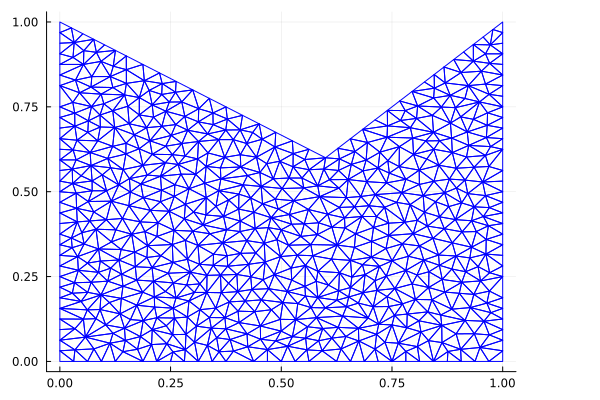

In [3]:
plt = plot()
x = mesh.pointlist[1,1:end]
y = mesh.pointlist[2,1:end]
for j=1:numberoftriangles(mesh)
    plt = plot!(
        [ x[mesh.trianglelist[1:3,j]]; x[mesh.trianglelist[1,j]]],
        [ y[mesh.trianglelist[1:3,j]]; y[mesh.trianglelist[1,j]]],
        color=:blue,
        label="",
        legend = :outertopright,
        )
end
plot(plt)



Los elementos de borde se almacenan en un objeto llamado `segment` 

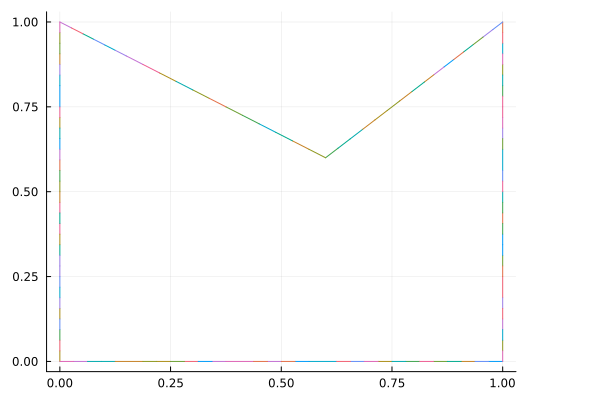

In [4]:
plt = plot()
for j=1:numberofsegments(mesh)
    plt = plot!(
        x[mesh.segmentlist[1:2,j]] ,
        y[mesh.segmentlist[1:2,j]],
        #color=:blue,
        label="",
        legend = :outertopright
        )
end
plot(plt)

# Área de un triángulo

In [5]:
function area_of_triangle(vertices)    
    # Formula de Heron para el area del triangulo de vértices vertices[1], vertices[2] y vertices[3]
    l1 = sqrt( (vertices[1][1]-vertices[2][1])^2 + (vertices[1][2] - vertices[2][2])^2 )
    l2 = sqrt( (vertices[2][1]-vertices[3][1])^2 + (vertices[2][2] - vertices[3][2])^2 )
    l3 = sqrt( (vertices[3][1]-vertices[1][1])^2 + (vertices[3][2] - vertices[1][2])^2 )
    s = ( l1 + l2 + l3 ) / 2
    return sqrt( s * (s-l1) * (s-l2) * (s-l3)  )
end

area_of_triangle (generic function with 1 method)

# Problema con condiciones de Dirichlet

Vamos a resolver el problema 
    $$-\Delta u = 1 \text{ en } \Omega, \qquad u = 0 \text{ en } \partial \Omega$$

## Construir la matriz de rigidez y el lado derecho sin incluir condiciones de contorno

Descomponemos
$$
    A_{ij} = \int_\Omega \nabla \phi_j \cdot \nabla \phi_i = \sum_{T \in \mathcal T} \int_T \nabla \phi_j \cdot \nabla \phi_i
$$

Para construir $A$ vamos a recorrer los triángulos, e ir añadiendo su contribución a cada $A_{ij}$ corrrespondiente. 



In [6]:
f(x) = 1;

npoints = size(mesh.pointlist,2)
b = zeros(npoints,1)

using SparseArrays
A = spzeros(npoints,npoints)

for T=1:numberoftriangles(mesh)
    indexes_of_vertices_of_T = mesh.trianglelist[:,T]
    vertices = [ mesh.pointlist[:,indexes_of_vertices_of_T[i]] for i in 1:3 ]
    
    area = area_of_triangle(vertices)

    #D[j,k] = ∂Φ_j/∂x_k
    D = zeros(3,2)  
    for j in 1:3
        D[j,:] = ∇ϕ(vertices,j)
    end
    
    # Matriz de rigidez
    for j in 1:3, k in 1:3
        A[indexes_of_vertices_of_T[j],indexes_of_vertices_of_T[k]]+= area*(D[j,1]*D[k,1] + D[j,2]*D[k,2])
    end

    # Lado derecho
    for j in 1:3
        b[indexes_of_vertices_of_T[j]]+= area*f(vertices[j])/3 # \int_T f \Phi_{index[j]}
    end
end

## Detectar puntos interiores

Para plantear el problema de Dirichlet homogéneo, fijamos a cero los nodos de borde, eliminándolos de la matriz del problema a resolver. 

Son fáciles de detectar: partimos de que todos los puntos son interiores, y vamos eliminando aquellos que sean el extremo de un segmento del borde.

In [7]:
# Primero tratado como un vector booleano
is_interior_point = Vector{Bool}(undef, npoints)
is_interior_point.= true
is_interior_point[ mesh.segmentlist[1,:] ] .= false
is_interior_point[ mesh.segmentlist[2,:] ] .= false;

## Añadir las condiciones de contorno homogéneas

Eliminando las ecuaciones e incógnitas correspondientes

In [8]:
Aᵣ = A[is_interior_point,is_interior_point]
bᵣ = b[is_interior_point]
ρᵣ = Aᵣ \ bᵣ

ρ  = zeros(npoints,1)
ρ[is_interior_point] = ρᵣ;

## Representación como superficie

Dada una lista de puntos $(x_i,y_i, \rho_i)$ la función ``surface`` construye y representa una superficie que los interpole

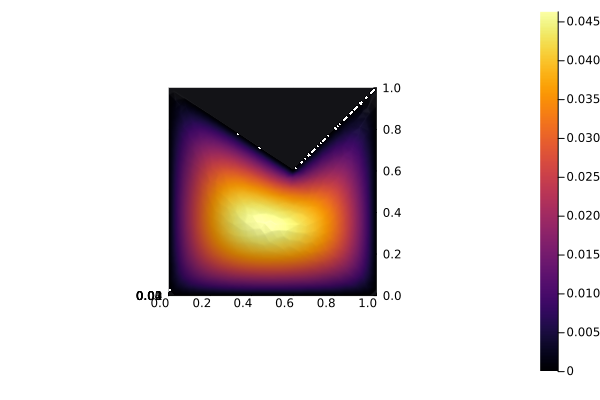

In [9]:
surface(vec(mesh.pointlist[1,:]), vec(mesh.pointlist[2,:]), vec(ρ), camera=(0,90))